In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

rt_clean = pd.read_csv(DATA_DIR / "rt_clean.csv")

final_trust_df = pd.read_csv(RESULTS_DIR / "final_trust_user_0_sample.csv")
recommendations_df = pd.read_csv(RESULTS_DIR / "top_n_recommendations_user_0.csv")
detection_metrics_df = pd.read_csv(RESULTS_DIR / "detection_metrics.csv")
access_df = pd.read_csv(RESULTS_DIR / "access_decisions_user_0.csv")
final_evaluation_df = pd.read_csv(RESULTS_DIR / "final_evaluation_metrics.csv")
summary_df = pd.read_csv(RESULTS_DIR / "final_result_summary.csv")

print("All files loaded successfully.")
print("RT clean:", rt_clean.shape)
print("Final trust:", final_trust_df.shape)
print("Recommendations:", recommendations_df.shape)
print("Detection metrics:", detection_metrics_df.shape)
print("Access decisions:", access_df.shape)
print("Final evaluation:", final_evaluation_df.shape)

Matplotlib is building the font cache; this may take a moment.


All files loaded successfully.
RT clean: (339, 5825)
Final trust: (20, 6)
Recommendations: (5, 7)
Detection metrics: (6, 2)
Access decisions: (5, 6)
Final evaluation: (8, 2)


In [2]:
thesis_result_overview = pd.DataFrame({
    "RDTMF Stage": [
        "Data Preprocessing",
        "Direct Trust Computation",
        "Indirect Trust Diffusion",
        "Weighted Trust Aggregation",
        "Anomaly Detection",
        "Top N Recommendation",
        "RBAC Access Decision",
        "Final Evaluation"
    ],
    "Main Output File": [
        "data/rt_clean.csv, data/rt_malicious.csv",
        "results/direct_trust_user_0_sample.csv",
        "results/indirect_trust_user_0_sample.csv",
        "results/final_trust_user_0_sample.csv",
        "results/flagged_users.csv, results/detection_metrics.csv",
        "results/top_n_recommendations_user_0.csv",
        "results/access_decisions_user_0.csv",
        "results/final_evaluation_metrics.csv"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

thesis_result_overview.to_csv(
    RESULTS_DIR / "thesis_result_overview.csv",
    index=False
)

thesis_result_overview

,RDTMF Stage,Main Output File,Status
0,Data Preprocessing,"data/rt_clean.csv, data/rt_malicious.csv",Completed
1,Direct Trust Computation,results/direct_trust_user_0_sample.csv,Completed
2,Indirect Trust Diffusion,results/indirect_trust_user_0_sample.csv,Completed
3,Weighted Trust Aggregation,results/final_trust_user_0_sample.csv,Completed
4,Anomaly Detection,"results/flagged_users.csv, results/detection_m...",Completed
5,Top N Recommendation,results/top_n_recommendations_user_0.csv,Completed
6,RBAC Access Decision,results/access_decisions_user_0.csv,Completed
7,Final Evaluation,results/final_evaluation_metrics.csv,Completed


In [3]:
final_evaluation_table = final_evaluation_df.copy()

final_evaluation_table["Value"] = final_evaluation_table["Value"].round(4)

final_evaluation_table.to_csv(
    RESULTS_DIR / "thesis_final_evaluation_table.csv",
    index=False
)

final_evaluation_table

,Metric,Value
0,MAE,0.0616
1,RMSE,0.0863
2,Coverage,1.0000
3,Precision@N,1.0000
4,Recall@N,0.2500
5,Detection Rate,1.0000
6,False Positive Rate,0.0000
7,Access Decision Consistency,1.0000


In [4]:
detection_table = detection_metrics_df.copy()

detection_table["value"] = detection_table["value"].round(4)

detection_table.to_csv(
    RESULTS_DIR / "thesis_detection_metrics_table.csv",
    index=False
)

detection_table

,metric,value
0,Known Malicious Users,34.0
1,Extreme Deviation Flagged Users,19.0
2,CUSUM Flagged Users,34.0
3,Total Combined Flagged Users,34.0
4,Detection Rate,1.0
5,False Positive Rate,0.0


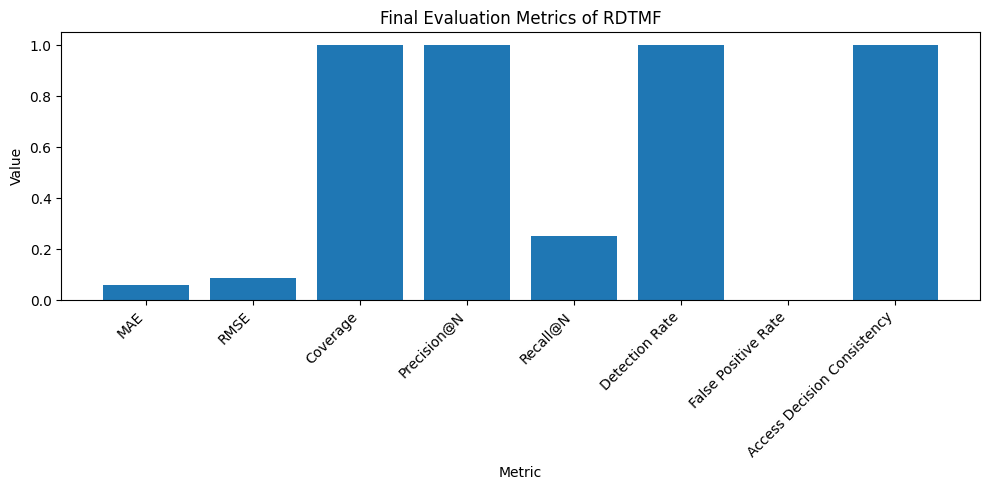

In [5]:
plot_df = final_evaluation_df.copy()
plot_df["Value"] = pd.to_numeric(plot_df["Value"], errors="coerce")
plot_df = plot_df.dropna()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Metric"], plot_df["Value"])
plt.title("Final Evaluation Metrics of RDTMF")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure_final_evaluation_metrics.png", dpi=300)
plt.show()

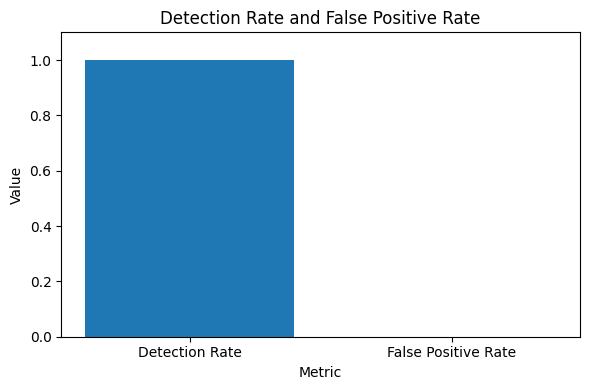

In [6]:
detection_plot = detection_metrics_df[
    detection_metrics_df["metric"].isin([
        "Detection Rate",
        "False Positive Rate"
    ])
].copy()

detection_plot["value"] = pd.to_numeric(detection_plot["value"], errors="coerce")

plt.figure(figsize=(6, 4))
plt.bar(detection_plot["metric"], detection_plot["value"])
plt.title("Detection Rate and False Positive Rate")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.ylim(0, 1.1)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure_detection_performance.png", dpi=300)
plt.show()

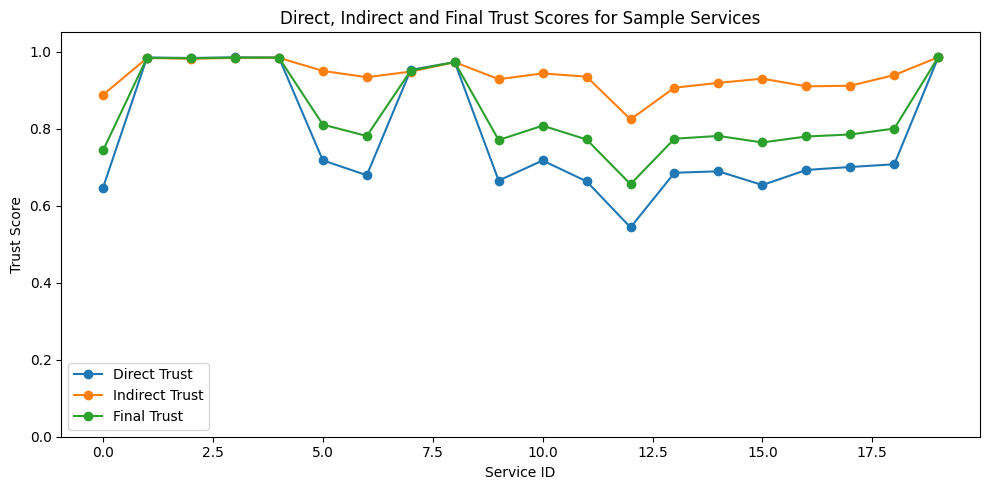

In [7]:
trust_plot = final_trust_df.copy()

plt.figure(figsize=(10, 5))
plt.plot(trust_plot["service_id"], trust_plot["direct_trust"], marker="o", label="Direct Trust")
plt.plot(trust_plot["service_id"], trust_plot["indirect_trust"], marker="o", label="Indirect Trust")
plt.plot(trust_plot["service_id"], trust_plot["final_trust"], marker="o", label="Final Trust")
plt.title("Direct, Indirect and Final Trust Scores for Sample Services")
plt.xlabel("Service ID")
plt.ylabel("Trust Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure_trust_score_comparison.png", dpi=300)
plt.show()

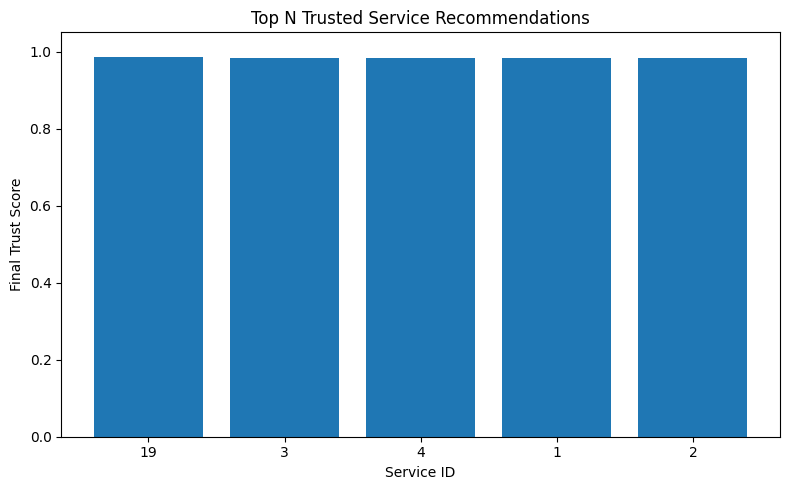

In [8]:
top_n_plot = recommendations_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(top_n_plot["service_id"].astype(str), top_n_plot["final_trust"])
plt.title("Top N Trusted Service Recommendations")
plt.xlabel("Service ID")
plt.ylabel("Final Trust Score")
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure_top_n_recommendations.png", dpi=300)
plt.show()

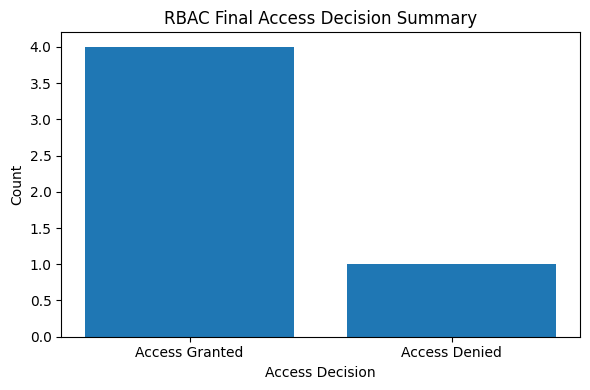

In [9]:
access_plot = access_df["access_decision"].value_counts().reset_index()
access_plot.columns = ["access_decision", "count"]

plt.figure(figsize=(6, 4))
plt.bar(access_plot["access_decision"], access_plot["count"])
plt.title("RBAC Final Access Decision Summary")
plt.xlabel("Access Decision")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "figure_access_decision_summary.png", dpi=300)
plt.show()

In [10]:
figure_list = pd.DataFrame({
    "Figure File": [
        "figure_final_evaluation_metrics.png",
        "figure_detection_performance.png",
        "figure_trust_score_comparison.png",
        "figure_top_n_recommendations.png",
        "figure_access_decision_summary.png"
    ],
    "Suggested Thesis Caption": [
        "Final evaluation metrics of the implemented RDTMF prototype.",
        "Detection performance under controlled 10% synthetic attack injection.",
        "Comparison of direct trust, indirect trust and final aggregated trust for sample services.",
        "Top N trusted services generated for the sample target user.",
        "Final access decision summary after RBAC policy enforcement."
    ]
})

figure_list.to_csv(
    RESULTS_DIR / "thesis_figure_list.csv",
    index=False
)

figure_list

,Figure File,Suggested Thesis Caption
0,figure_final_evaluation_metrics.png,Final evaluation metrics of the implemented RD...
1,figure_detection_performance.png,Detection performance under controlled 10% syn...
2,figure_trust_score_comparison.png,"Comparison of direct trust, indirect trust and..."
3,figure_top_n_recommendations.png,Top N trusted services generated for the sampl...
4,figure_access_decision_summary.png,Final access decision summary after RBAC polic...


In [11]:
detection_rate_value = float(
    detection_metrics_df.loc[
        detection_metrics_df["metric"] == "Detection Rate",
        "value"
    ].iloc[0]
)

fpr_value = float(
    detection_metrics_df.loc[
        detection_metrics_df["metric"] == "False Positive Rate",
        "value"
    ].iloc[0]
)

highest_trust = recommendations_df["final_trust"].max()
lowest_trust = recommendations_df["final_trust"].min()

result_paragraph = f"""
The initial implementation of the RDTMF prototype successfully completed the main computational stages defined in the conceptual framework. The WS-DREAM response-time matrix was preprocessed, transformed into a normalised quality-score matrix and used to generate clean and malicious experimental datasets. Direct trust was computed using rating-based similarity, while indirect trust was produced using BFS-based trust diffusion. These values were combined through weighted trust aggregation to produce final trust scores. In the controlled 10% synthetic malicious-user injection experiment, the anomaly detection module achieved a detection rate of {detection_rate_value:.2f} and a false positive rate of {fpr_value:.2f}. The Top N recommendation module produced five trusted service recommendations for the sample target user, with final trust scores ranging from {lowest_trust:.4f} to {highest_trust:.4f}. The final access-control stage then applied RBAC policy checking to convert trusted recommendations into access-granted or access-denied outcomes. These results show that the implemented prototype can generate traceable outputs for trust computation, malicious-user filtering, recommendation and access decision-making.
"""

with open(RESULTS_DIR / "chapter7_initial_findings_paragraph.txt", "w") as f:
    f.write(result_paragraph)

print(result_paragraph)


The initial implementation of the RDTMF prototype successfully completed the main computational stages defined in the conceptual framework. The WS-DREAM response-time matrix was preprocessed, transformed into a normalised quality-score matrix and used to generate clean and malicious experimental datasets. Direct trust was computed using rating-based similarity, while indirect trust was produced using BFS-based trust diffusion. These values were combined through weighted trust aggregation to produce final trust scores. In the controlled 10% synthetic malicious-user injection experiment, the anomaly detection module achieved a detection rate of 1.00 and a false positive rate of 0.00. The Top N recommendation module produced five trusted service recommendations for the sample target user, with final trust scores ranging from 0.9827 to 0.9852. The final access-control stage then applied RBAC policy checking to convert trusted recommendations into access-granted or access-denied outcomes. 

In [12]:
for file in FIGURES_DIR.iterdir():
    print(file)

print("\nResult tables:")
for file in RESULTS_DIR.iterdir():
    if file.suffix == ".csv":
        print(file)

results/figures/figure_trust_score_comparison.png
results/figures/figure_top_n_recommendations.png
results/figures/figure_final_evaluation_metrics.png
results/figures/figure_detection_performance.png
results/figures/figure_access_decision_summary.png

Result tables:
results/top_n_recommendations_user_0.csv
results/recommendation_summary_user_0.csv
results/final_evaluation_metrics.csv
results/thesis_final_evaluation_table.csv
results/direct_trust_user_0_sample.csv
results/detection_metrics.csv
results/access_decision_summary_user_0.csv
results/thesis_detection_metrics_table.csv
results/final_trust_user_0_sample.csv
results/thesis_figure_list.csv
results/thesis_result_overview.csv
results/flagged_users.csv
results/access_decisions_user_0.csv
results/indirect_trust_user_0_sample.csv
results/final_result_summary.csv
